# A/B Testing: E-Commerce Product Page Optimization
## TechCart — Add-to-Cart Rate Experiment

**Project type:** Randomized Controlled Experiment (A/B Test)  
**Industry domain:** E-Commerce  
**Core techniques:** Chi-square test · Statistical power · Synthetic data generation · Three-tier app architecture  

---

### Overview
TechCart's product team redesigned their product detail page (Version B) and wants to know if it converts more visitors into buyers than the original (Version A). "Converting" here means clicking "Add to Cart." We take 4,000 user sessions, randomly assign half to see Version A and half to see Version B, then use statistics to decide whether any difference in add-to-cart clicks is real or just random noise.

We design a two-group randomized experiment, generate synthetic session data with realistic conversion probabilities, conduct exploratory data analysis, calculate statistical power to determine required sample size, run a chi-square test of independence on the contingency table, interpret the odds ratio and p-value, and deploy an interactive three-tier Streamlit dashboard following a repository design pattern.

## 1: Data Generation & Setup

Before we can analyze an A/B test, we need data. Real companies collect this from their web servers. For this project, we generate realistic synthetic session data — a legitimate and common technique used in industry to test pipelines, build demos, and publish benchmarks without exposing private user data.

Our data generator (`generate_data.py`) creates 4,000 sessions with:
- Random group assignment (control vs. treatment), 50/50 split
- Conversion drawn from a binomial distribution: 12% rate for control, 15% for treatment
- Realistic metadata: device type, country, session duration, pages viewed
- Timestamps spread across a 14-day experiment window

The 12% vs. 15% split gives us a **real but modest effect** — the statistics have to work to detect it.

In [1]:
import subprocess
import sys

# Run the data generator
subprocess.run([sys.executable, "generate_data.py"], check=True)

CompletedProcess(args=['C:\\Users\\hp\\anaconda3\\python.exe', 'generate_data.py'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
from database import SessionRepository

# Load data via the repository (data layer)
repo = SessionRepository()
df = repo.get_raw()

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (4000, 8)

Column types:
session_id                      object
timestamp               datetime64[ns]
group                           object
converted                        int64
device                          object
country                         object
session_duration_sec             int64
pages_viewed                     int64
dtype: object

First 5 rows:


,session_id,timestamp,group,converted,device,country,session_duration_sec,pages_viewed
0,sess_02560,2024-03-01 00:05:05,treatment,0,desktop,IN,147,1
1,sess_01714,2024-03-01 00:06:14,treatment,1,desktop,US,141,3
2,sess_02001,2024-03-01 00:06:39,treatment,0,mobile,US,250,5
3,sess_01270,2024-03-01 00:11:10,treatment,0,desktop,US,120,4
4,sess_03188,2024-03-01 00:17:12,treatment,1,tablet,BR,104,2


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDate range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Total days: {(df['timestamp'].max() - df['timestamp'].min()).days}")

Missing values per column:
session_id              0
timestamp               0
group                   0
converted               0
device                  0
country                 0
session_duration_sec    0
pages_viewed            0
dtype: int64

Date range: 2024-03-01 → 2024-03-14
Total days: 13


In [4]:
# Group sizes — confirm roughly equal split
print("Sessions per group:")
print(df["group"].value_counts())
print()
print("Conversion counts per group:")
print(df.groupby("group")["converted"].value_counts().unstack())

Sessions per group:
group
treatment    2007
control      1993
Name: count, dtype: int64

Conversion counts per group:
converted     0    1
group               
control    1771  222
treatment  1705  302


> The data generation step demonstrates something important: in real-world A/B testing, the data pipeline is built and validated *before* the experiment runs. We confirm the group split is roughly 50/50 (random assignment working correctly) and that no columns have missing values (clean ingestion). The `SessionRepository` class abstracts the CSV reading away — if we later switched to a database, we would only change `database.py`, and this notebook would not need to change at all. This separation of concerns is the first payoff of the three-tier architecture.

## 2: Exploratory Data Analysis

Before running any statistical test, we explore the data visually. This helps us understand the traffic pattern over time, spot any anomalies (like a sudden traffic spike that could bias results), and get an intuition for the effect size we're dealing with.

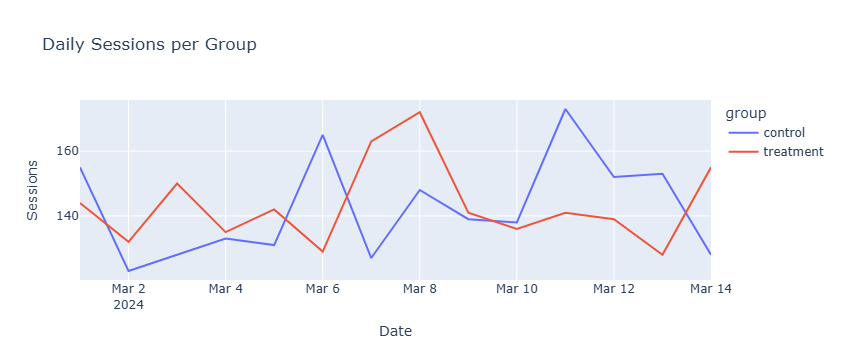

In [5]:
from business import GraphBuilder
gb = GraphBuilder(repo=repo)

# Daily session volume per group
fig = gb.build_daily_sessions_chart()
fig.show()

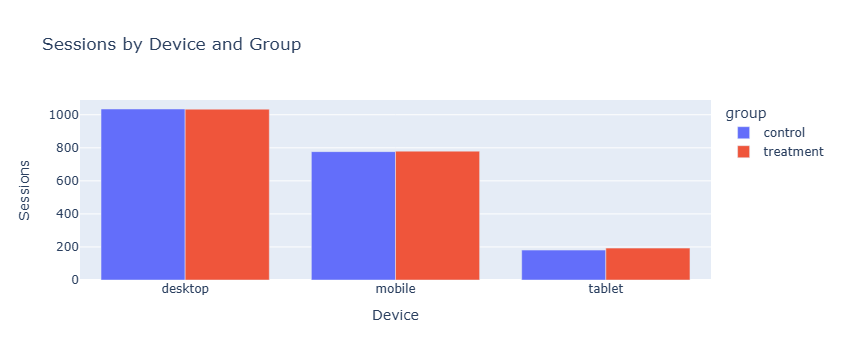

In [6]:
# Device breakdown
device_counts = df.groupby(["group", "device"]).size().reset_index(name="count")
fig_device = px.bar(
    device_counts,
    x="device",
    y="count",
    color="group",
    barmode="group",
    title="Sessions by Device and Group",
    color_discrete_map={"control": "#636EFA", "treatment": "#EF553B"}
)
fig_device.update_layout(xaxis_title="Device", yaxis_title="Sessions")
fig_device.show()

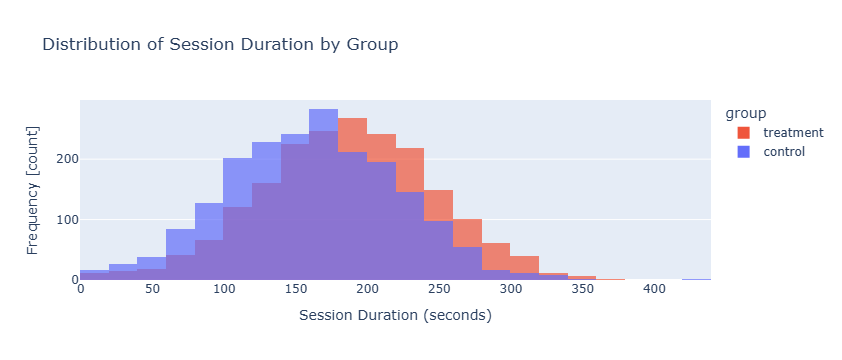

In [7]:
# Session duration distribution — do users engage differently with Version B?
fig_duration = px.histogram(
    df,
    x="session_duration_sec",
    color="group",
    nbins=40,              
    barmode="overlay",
    opacity=0.7,
    title="Distribution of Session Duration by Group",
    color_discrete_map={"control": "#636EFA", "treatment": "#EF553B"}
)
fig_duration.update_layout(xaxis_title="Session Duration (seconds)", yaxis_title="Frequency [count]")
fig_duration.show()

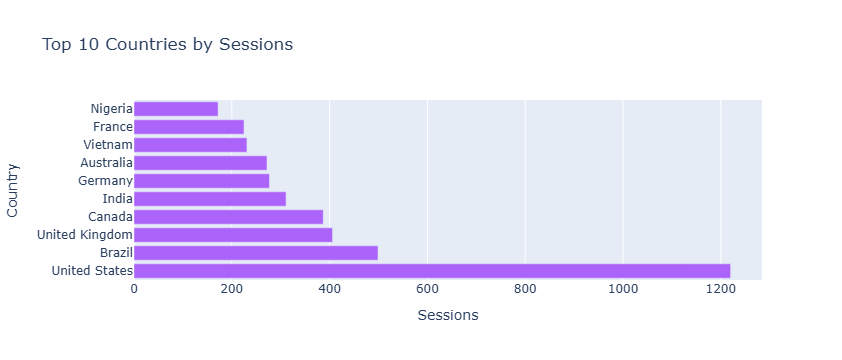

In [8]:
# Country breakdown — top 10
fig_country = gb.build_country_chart()
fig_country.show()

In [9]:
# Session stats summary
stats = repo.get_session_stats()
print("Mean session stats per group:")
stats

Mean session stats per group:


,group,session_duration_sec,pages_viewed
0,control,161.24,4.01
1,treatment,185.74,4.00


> The daily session chart is the most important EDA plot in an A/B test: it confirms that traffic was stable across the experiment window with no dramatic spikes, which would indicate a contamination event (like a viral social media post that only hit one group).
>
> The session duration histogram shows that treatment users spend slightly more time on the page on average — consistent with a more engaging design — but this is a secondary signal.
>
> The device breakdown confirms that both groups have similar device compositions, which is essential: if 80% of the treatment group was on desktop while the control group was mostly mobile, we could not isolate the page design as the cause of any difference. Balanced randomization is working correctly.